# SKU-Level Forecasting: CA_1, All Categories

Everything through `05_recursive_forecast.ipynb` worked at the category-aggregated level: one row per day, `total_sales` summed across every FOODS item in CA_1. That's a smooth, easy signal for a model to learn.

This notebook goes to the level a real forecasting system actually needs: one row per item per day, across all three categories (FOODS, HOBBIES, HOUSEHOLD), still CA_1 only. One global model is trained across all 3,049 items rather than a separate model per item or per category, and evaluated with the same leakage-safe recursive approach established in `05_recursive_forecast.ipynb`.

Two things change in kind, not just in scale, versus the earlier notebooks:
- Lag and rolling features have to be computed **within each item's own history** (`groupby('item_id')`), not across the whole dataset, or one item's sales would leak into the next item's lag features.
- The model needs to know *which* item, department, and category each row belongs to, which means introducing categorical features for the first time in this project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
import warnings
import os
warnings.filterwarnings('ignore')

print("Imports ready")

Imports ready


## Building the item-level dataset

Same melt-and-merge approach `01_exploration.ipynb` used to build `subset_long_CA1_FOODS.csv`, just without the `cat_id` filter, so all three categories for CA_1 come through instead of just FOODS. Saved as `data/processed/subset_long_CA1_ALL.csv`.

In [2]:
sales = pd.read_csv('../data/raw/sales_train_evaluation.csv')
calendar = pd.read_csv('../data/raw/calendar.csv')

STORE = 'CA_1'
subset = sales[sales['store_id'] == STORE].copy()

print(f"Store: {STORE}")
print(f"Items: {len(subset):,}")
print(subset['cat_id'].value_counts())

Store: CA_1
Items: 3,049
cat_id
FOODS        1437
HOUSEHOLD    1047
HOBBIES       565
Name: count, dtype: int64


In [3]:
day_cols = [c for c in subset.columns if c.startswith('d_')]

subset_long = subset.melt(
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    value_vars=day_cols,
    var_name='d',
    value_name='sales'
)

subset_long = subset_long.merge(
    calendar[['d', 'date', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'snap_CA']],
    on='d',
    how='left'
)
subset_long['date'] = pd.to_datetime(subset_long['date'])

os.makedirs('../data/processed', exist_ok=True)
subset_long.to_csv('../data/processed/subset_long_CA1_ALL.csv', index=False)

print(f"Item-level shape: {subset_long.shape}")
print(f"Date range: {subset_long['date'].min().date()} to {subset_long['date'].max().date()}")
print("Saved to data/processed/subset_long_CA1_ALL.csv")

Item-level shape: (5918109, 15)
Date range: 2011-01-29 to 2016-05-22
Saved to data/processed/subset_long_CA1_ALL.csv


## Feature engineering: per-item lags, and new categorical features

**Why `groupby` matters here.** The dataset is sorted by `(item_id, date)`. A plain `df['sales'].shift(7)`, the approach used in `03`/`05`, would work fine on a single series, but here it would walk straight across item boundaries: the first few rows of item B would get lag values pulled from the last few rows of item A. Grouping by `item_id` before shifting keeps every lag and rolling feature confined to that item's own history, and correctly produces `NaN` for each item's own first few days instead of a leaked value from a different item.

**Categorical encoding.** `item_id` has 3,049 unique values in CA_1. One-hot encoding it would add 3,000+ columns across ~5.9M rows, impractical for `GradientBoostingRegressor`, which (unlike `HistGradientBoostingRegressor` or LightGBM) has no native categorical support and works on a dense array. So `item_id` is encoded as integer category codes instead: the tree-based model doesn't need true ordinal meaning to split usefully on it, it just needs a consistent way to separate items during splits. `dept_id` (7 values) and `cat_id` (3 values) are cheap to one-hot at that cardinality, which avoids the false-ordering problem entirely for those two, since there's no meaningful cost to doing so.

The category code and one-hot mappings are both fixed once from the full dataset's unique values, and reused identically during recursive forecasting later, so a given item always gets the same code and the same dummy columns whether it's being trained on or predicted for.

In [4]:
def create_features_grouped(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['item_id', 'date']).reset_index(drop=True)

    # Calendar features - identical for every item on a given date, safe to compute globally
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['quarter'] = df['date'].dt.quarter

    # Lag and rolling features - grouped by item_id so one item's history never
    # leaks into another item's lag/rolling values (see markdown above).
    grouped_sales = df.groupby('item_id')['sales']
    df['lag_7'] = grouped_sales.shift(7)
    df['lag_14'] = grouped_sales.shift(14)
    df['lag_28'] = grouped_sales.shift(28)

    shifted = grouped_sales.shift(1)
    df['rolling_mean_7'] = shifted.groupby(df['item_id']).rolling(7).mean().reset_index(level=0, drop=True)
    df['rolling_mean_28'] = shifted.groupby(df['item_id']).rolling(28).mean().reset_index(level=0, drop=True)
    df['rolling_std_7'] = shifted.groupby(df['item_id']).rolling(7).std().reset_index(level=0, drop=True)

    return df

print("create_features_grouped defined")

create_features_grouped defined


In [5]:
# Fixed category vocabularies, computed once and reused everywhere (including inside
# the recursive forecast loop) so item_id codes and one-hot columns stay identical
# between training and forecasting.
item_categories = sorted(subset_long['item_id'].unique())
dept_categories = sorted(subset_long['dept_id'].unique())
cat_categories = sorted(subset_long['cat_id'].unique())

item_lookup = subset_long[['item_id', 'dept_id', 'cat_id']].drop_duplicates().reset_index(drop=True)

def add_categorical_features(df):
    df = df.copy()
    df['item_id_code'] = pd.Categorical(df['item_id'], categories=item_categories).codes

    dept_dummies = pd.get_dummies(
        pd.Categorical(df['dept_id'], categories=dept_categories), prefix='dept'
    )
    cat_dummies = pd.get_dummies(
        pd.Categorical(df['cat_id'], categories=cat_categories), prefix='cat'
    )
    dept_dummies.index = df.index
    cat_dummies.index = df.index

    return pd.concat([df, dept_dummies, cat_dummies], axis=1)

feature_cols = [
    'day_of_week', 'day_of_month', 'month', 'year',
    'week_of_year', 'is_weekend', 'quarter',
    'lag_7', 'lag_14', 'lag_28',
    'rolling_mean_7', 'rolling_mean_28', 'rolling_std_7',
    'item_id_code'
] + [f'dept_{d}' for d in dept_categories] + [f'cat_{c}' for c in cat_categories]

print(f"Items: {len(item_categories):,}")
print(f"Depts: {dept_categories}")
print(f"Cats:  {cat_categories}")
print(f"Total feature columns: {len(feature_cols)}")

Items: 3,049
Depts: ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']
Cats:  ['FOODS', 'HOBBIES', 'HOUSEHOLD']
Total feature columns: 24


In [6]:
FORECAST_HORIZON = 28

full_data = create_features_grouped(subset_long[['item_id', 'dept_id', 'cat_id', 'date', 'sales']])
full_data = add_categorical_features(full_data)

cutoff_date = full_data['date'].max() - pd.Timedelta(days=FORECAST_HORIZON)
train = full_data[full_data['date'] <= cutoff_date].copy()
test = full_data[full_data['date'] > cutoff_date].copy()

rows_before_dropna = len(train)
train = train.dropna(subset=feature_cols)

print(f"Full shape after feature engineering: {full_data.shape}")
print(f"Train: {train['date'].min().date()} to {train['date'].max().date()} ({len(train):,} rows)")
print(f"Test:  {test['date'].min().date()} to {test['date'].max().date()} ({len(test):,} rows, {test['item_id'].nunique():,} items)")
print(f"Rows dropped for lag warm-up (per-item, not global): {rows_before_dropna - len(train):,}")

Full shape after feature engineering: (5918109, 29)
Train: 2011-02-26 to 2016-04-24 (5,747,365 rows)
Test:  2016-04-25 to 2016-05-22 (85,372 rows, 3,049 items)
Rows dropped for lag warm-up (per-item, not global): 85,372


## Training one global model

Same tuned hyperparameters as `03_xgboost_model.ipynb` / `05_recursive_forecast.ipynb`: `n_estimators=100, learning_rate=0.05, max_depth=7, subsample=0.8`. No grid search here — 03's 27-combination search took seconds on ~1,900 rows; at several million training rows, the same search would take dramatically longer just to establish a starting point, so these values are used as-is. If they turn out to underperform noticeably, that's worth its own follow-up notebook rather than folding a long tuning run into this one.

Trained strictly on `train`, same as `05`, so no test-period data is involved in fitting.

In [7]:
X_train = train[feature_cols]
y_train = train['sales']

model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    random_state=42
)
model.fit(X_train, y_train)

print("Model trained on training data only.")
print(f"Training rows: {len(X_train):,} | Features: {len(feature_cols)}")

Model trained on training data only.
Training rows: 5,747,365 | Features: 24


## Recursive forecasting across all items

Same idea as `05_recursive_forecast.ipynb`: predict one day, feed it back in as if it were real, move to the next day, so no prediction ever sees real future data. The difference here is scale: 3,049 items, one prediction per item per day.

Two changes from `05`'s loop, both purely about keeping this tractable at scale, not about the forecasting logic itself:

- **Batched per day, not per item.** A naive extension of `05` would loop per item and then per day (or vice versa): 3,049 x 28 = 85,372 individual `model.predict()` calls. Instead, each of the 28 steps predicts all 3,049 items at once with a single batched call, so the loop only runs 28 times total.
- **Bounded history window, not the full growing history.** `05` re-ran feature engineering over the entire history at every step, which is fine for one series. Every feature this model uses (`lag_28`, `rolling_mean_28`, etc.) only ever looks back 28 days, so each item only needs its trailing 28 days carried forward, not its full ~5-year history. Recomputing features over a ~85K-row window (3,049 items x 28 days) each step, instead of a multi-million-row one, keeps the loop fast without changing the result: the feature values produced are identical either way, since nothing beyond 28 days back is ever read.

Predictions are clipped at 0, since negative predicted sales aren't meaningful and would otherwise get fed back in as history for the next step.

In [8]:
LAG_WINDOW = 28

def recursive_forecast_multi(model, history_df, horizon, feature_cols, item_lookup):
    # history_df: last LAG_WINDOW real days per item, columns item_id, dept_id, cat_id, date, sales
    history = history_df.copy()
    last_date = history['date'].max()
    all_predictions = []

    for step in range(horizon):
        next_date = last_date + pd.Timedelta(days=step + 1)

        next_rows = item_lookup.copy()
        next_rows['date'] = next_date
        next_rows['sales'] = np.nan

        window = pd.concat([history, next_rows], ignore_index=True)
        window_features = create_features_grouped(window)
        window_features = add_categorical_features(window_features)

        next_mask = window_features['date'] == next_date
        X_next = window_features.loc[next_mask, feature_cols]
        preds = np.clip(model.predict(X_next), 0, None)

        step_result = window_features.loc[next_mask, ['item_id', 'date']].copy()
        step_result['prediction'] = preds
        all_predictions.append(step_result)

        next_rows_actual = next_rows.copy()
        next_rows_actual['sales'] = preds
        history = pd.concat([history, next_rows_actual], ignore_index=True)

        # keep only the trailing LAG_WINDOW days per item
        history = (history
            .sort_values(['item_id', 'date'])
            .groupby('item_id', group_keys=False)
            .tail(LAG_WINDOW))

    return pd.concat(all_predictions, ignore_index=True)

print("recursive_forecast_multi defined")

recursive_forecast_multi defined


In [9]:
history_init = (train[['item_id', 'dept_id', 'cat_id', 'date', 'sales']]
    .sort_values(['item_id', 'date'])
    .groupby('item_id', group_keys=False)
    .tail(LAG_WINDOW))

print(f"History window: {history_init['item_id'].nunique():,} items x last {LAG_WINDOW} days each = {len(history_init):,} rows")

recursive_preds = recursive_forecast_multi(
    model=model,
    history_df=history_init,
    horizon=FORECAST_HORIZON,
    feature_cols=feature_cols,
    item_lookup=item_lookup
)

print(f"Recursive predictions: {len(recursive_preds):,} rows ({recursive_preds['item_id'].nunique():,} items x {FORECAST_HORIZON} days)")

History window: 3,049 items x last 28 days each = 85,372 rows


Recursive predictions: 85,372 rows (3,049 items x 28 days)


## Evaluation: aggregate and by category

Same MAPE convention as `03`/`05`: actual-zero rows are masked out, since MAPE is undefined (division by zero) otherwise. MAE is reported alongside because it doesn't have that problem and is a fairer comparison across items with very different volumes; a lot of items here, especially in HOBBIES, sell in the low single digits per day, and a 1-2 unit miss on those can swing MAPE sharply even though the absolute error is small. Both metrics are reported at the aggregate level (all items, all days) and broken down by category, since FOODS, HOBBIES, and HOUSEHOLD have very different volume and intermittency profiles in this data. Noisier per-item and per-category MAPE than the category-aggregated result in `05` is expected here, not a sign of a bug.

In [10]:
def mape(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    mask = actual > 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def mae(actual, predicted):
    return np.mean(np.abs(np.array(actual) - np.array(predicted)))

eval_df = recursive_preds.merge(
    test[['item_id', 'date', 'sales', 'cat_id']],
    on=['item_id', 'date'],
    how='left'
).rename(columns={'sales': 'actual'})

overall_mape = mape(eval_df['actual'], eval_df['prediction'])
overall_mae = mae(eval_df['actual'], eval_df['prediction'])

print("=== SKU-LEVEL RESULTS (ALL CATEGORIES, CA_1) ===")
print(f"MAPE: {overall_mape:.1f}%")
print(f"MAE:  {overall_mae:.2f} units/item/day")

=== SKU-LEVEL RESULTS (ALL CATEGORIES, CA_1) ===
MAPE: 59.4%
MAE:  1.61 units/item/day


In [11]:
category_results = (eval_df
    .groupby('cat_id')
    .apply(lambda g: pd.Series({
        'MAPE (%)': mape(g['actual'], g['prediction']),
        'MAE': mae(g['actual'], g['prediction']),
        'avg_daily_sales': g['actual'].mean(),
        'items': g['item_id'].nunique()
    }))
    .round(2)
)

print("=== RESULTS BY CATEGORY ===")
print(category_results)

=== RESULTS BY CATEGORY ===
           MAPE (%)   MAE  avg_daily_sales   items
cat_id                                            
FOODS         57.29  1.96             2.26  1437.0
HOBBIES       56.58  1.29             0.97   565.0
HOUSEHOLD     64.73  1.29             0.95  1047.0


## Baseline: seasonal naive

Everything above compares this notebook's SKU-level result against `05`'s category-level result (5.5% MAPE), but that's a different granularity, not a proper baseline at this level. `02_baseline_models.ipynb` established naive/moving-average/seasonal-naive baselines for the category-aggregated series; this repeats that check here, at SKU level, to see whether the model is actually earning its complexity.

**Seasonal naive**: for each item, repeat its last real 7 days (same weekday last week) across the full 28-day horizon. This needs no recursion, since the entire forecast is a fixed tiling of one real week, and it's leakage-safe by construction: every value it uses is real data from strictly before the forecast window starts.

In [12]:
last_week = subset_long[
    (subset_long['date'] >= cutoff_date - pd.Timedelta(days=6)) & (subset_long['date'] <= cutoff_date)
][['item_id', 'date', 'sales']].copy()
last_week = last_week.sort_values(['item_id', 'date'])
last_week['dow_pos'] = last_week.groupby('item_id').cumcount()

seasonal_eval = test[['item_id', 'date', 'sales', 'cat_id']].copy()
seasonal_eval['dow_pos'] = ((seasonal_eval['date'] - (cutoff_date + pd.Timedelta(days=1))).dt.days) % 7
seasonal_eval = seasonal_eval.merge(
    last_week[['item_id', 'dow_pos', 'sales']].rename(columns={'sales': 'seasonal_pred'}),
    on=['item_id', 'dow_pos'],
    how='left'
)

seasonal_mape = mape(seasonal_eval['sales'], seasonal_eval['seasonal_pred'])
seasonal_mae = mae(seasonal_eval['sales'], seasonal_eval['seasonal_pred'])

print("=== SEASONAL NAIVE BASELINE (SKU-LEVEL, SAME TEST WINDOW) ===")
print(f"MAPE: {seasonal_mape:.1f}%")
print(f"MAE:  {seasonal_mae:.2f} units/item/day")

=== SEASONAL NAIVE BASELINE (SKU-LEVEL, SAME TEST WINDOW) ===
MAPE: 83.3%
MAE:  1.36 units/item/day


In [13]:
seasonal_by_cat = (seasonal_eval
    .groupby('cat_id')
    .apply(lambda g: pd.Series({
        'MAPE (%)': mape(g['sales'], g['seasonal_pred']),
        'MAE': mae(g['sales'], g['seasonal_pred'])
    }), include_groups=False)
    .round(2)
)

print("=== SEASONAL NAIVE BY CATEGORY ===")
print(seasonal_by_cat)

=== SEASONAL NAIVE BY CATEGORY ===
           MAPE (%)   MAE
cat_id                   
FOODS         83.00  1.76
HOBBIES       91.24  1.12
HOUSEHOLD     80.24  0.95


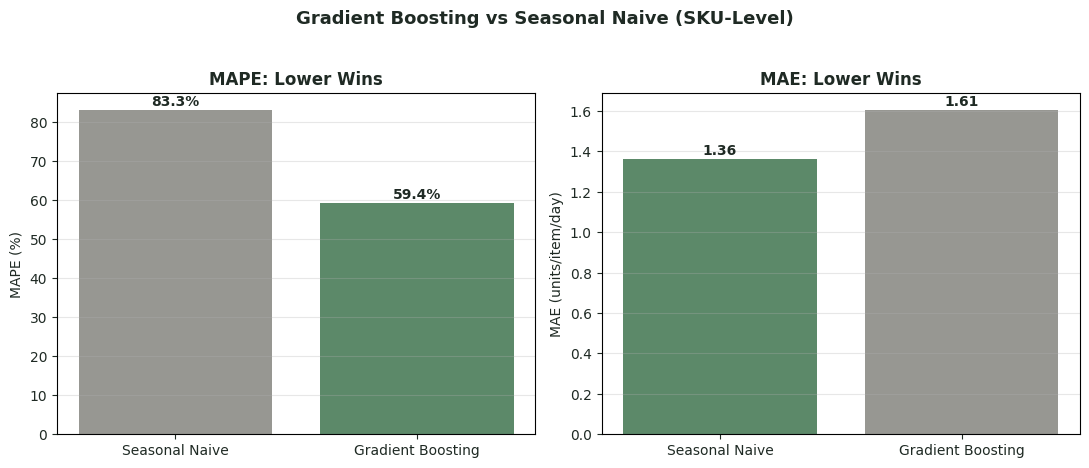

In [14]:
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor='white')

models = ['Seasonal Naive', 'Gradient Boosting']
mapes = [seasonal_mape, overall_mape]
maes = [seasonal_mae, overall_mae]

axes[0].bar(models, mapes, color=['#4A7C59' if m == min(mapes) else '#8C8C86' for m in mapes], alpha=0.9)
axes[0].set_title('MAPE: Lower Wins', fontsize=12, fontweight='bold', color='#1F2A24')
axes[0].set_ylabel('MAPE (%)', color='#1F2A24')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(mapes):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', color='#1F2A24')

axes[1].bar(models, maes, color=['#4A7C59' if m == min(maes) else '#8C8C86' for m in maes], alpha=0.9)
axes[1].set_title('MAE: Lower Wins', fontsize=12, fontweight='bold', color='#1F2A24')
axes[1].set_ylabel('MAE (units/item/day)', color='#1F2A24')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(maes):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold', color='#1F2A24')

for ax in axes:
    ax.set_facecolor('white')
    ax.tick_params(colors='#1F2A24')

plt.suptitle('Gradient Boosting vs Seasonal Naive (SKU-Level)', fontsize=13, fontweight='bold', color='#1F2A24', y=1.03)
plt.tight_layout()
plt.savefig('../images/baseline_comparison_sku.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

**The result doesn't point one direction, and that's worth stating plainly rather than glossing over.** Gradient Boosting clearly wins on MAPE, by a wide margin, in every category. But seasonal naive has the *lower* MAE, also in every category. Which model is "better" here depends on which metric matters for the use case.

A plausible reason: `rolling_mean_7` dominates this model's feature importance (see below), so its predictions behave like a smoothed average. That smoothing reduces *percentage* error broadly across the many low-volume, intermittent items where MAPE is calculated (a smoothed prediction rarely misses by a huge percentage). But smoothing also means it doesn't fully track the sharper day-to-day swings on the relatively few higher-volume items, and those items contribute disproportionately to a raw-unit metric like MAE, since MAE isn't normalized by scale. Seasonal naive, by just replaying last week exactly, tracks those swings more faithfully on average in absolute terms, even though it's far worse at avoiding large *percentage* misses on the long tail of low-volume items.

Practical takeaway: at SKU level, the model is a clear improvement if percentage accuracy matters (e.g., relative forecast quality across items of very different sizes). If the operational cost is roughly linear in units of error (e.g., overstock/understock cost per unit), seasonal naive is a legitimate, much simpler alternative worth keeping in mind, not something this model unambiguously beats.

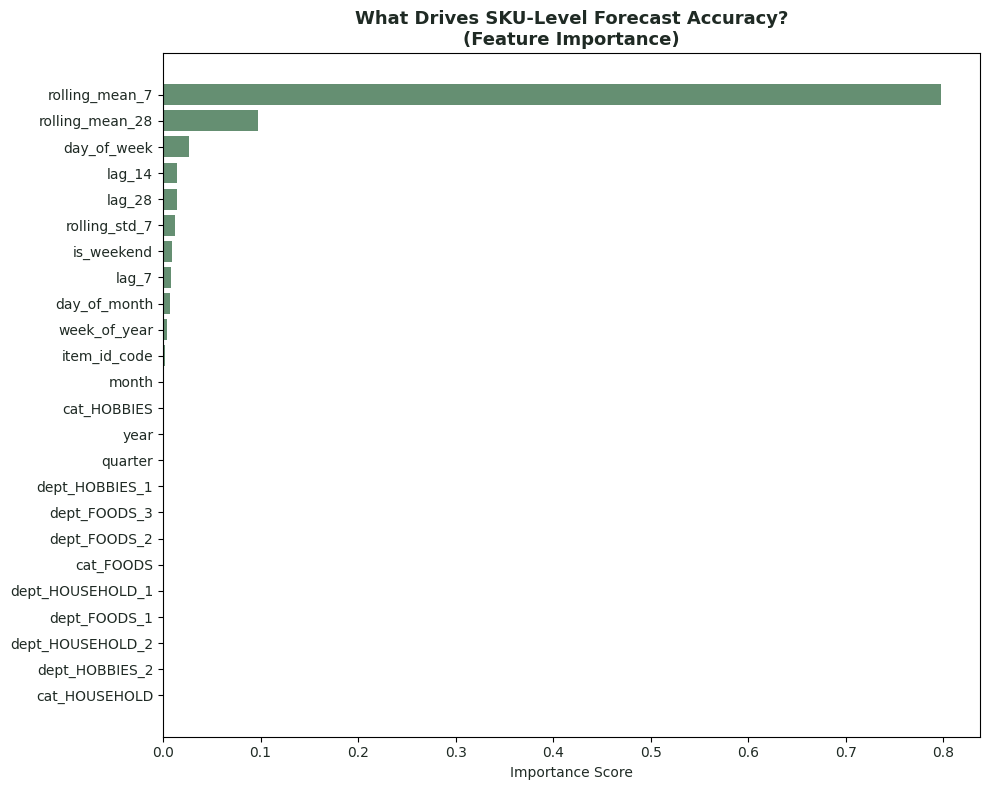

In [15]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.style.use('default')
plt.figure(figsize=(10, 8), facecolor='white')
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#4A7C59', alpha=0.85)
plt.title('What Drives SKU-Level Forecast Accuracy?\n(Feature Importance)',
          fontsize=13, fontweight='bold', color='#1F2A24')
plt.xlabel('Importance Score', color='#1F2A24')
plt.xticks(color='#1F2A24')
plt.yticks(color='#1F2A24')
plt.gca().set_facecolor('white')
plt.tight_layout()
plt.savefig('../images/feature_importance_sku.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

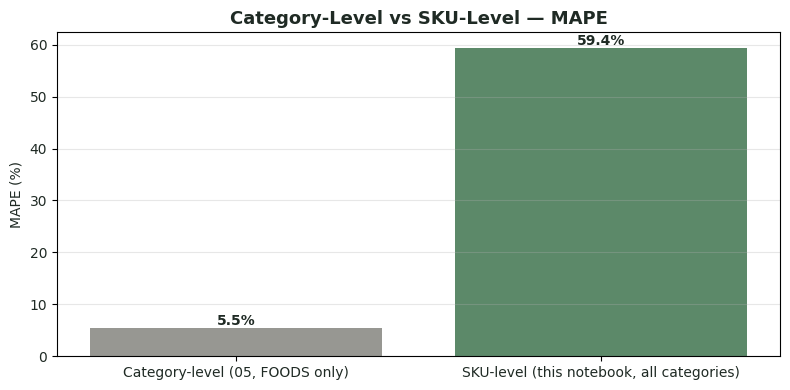

In [16]:
comparison = pd.DataFrame({
    'Model': [
        'Category-level (05, FOODS only)',
        'SKU-level (this notebook, all categories)'
    ],
    'MAPE (%)': [5.5, overall_mape]
})

plt.style.use('default')
plt.figure(figsize=(8, 4), facecolor='white')
colors = ['#8C8C86', '#4A7C59']
plt.bar(comparison['Model'], comparison['MAPE (%)'], color=colors, alpha=0.9)
plt.title('Category-Level vs SKU-Level — MAPE', fontsize=13, fontweight='bold', color='#1F2A24')
plt.ylabel('MAPE (%)', color='#1F2A24')
plt.xticks(color='#1F2A24')
plt.yticks(color='#1F2A24')
plt.grid(True, alpha=0.3, axis='y')
for i, (model_name, mape_val) in enumerate(zip(comparison['Model'], comparison['MAPE (%)'])):
    plt.text(i, mape_val + 0.5, f'{mape_val:.1f}%', ha='center', fontweight='bold', color='#1F2A24')
plt.gca().set_facecolor('white')
plt.tight_layout()
plt.savefig('../images/model_comparison_sku.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

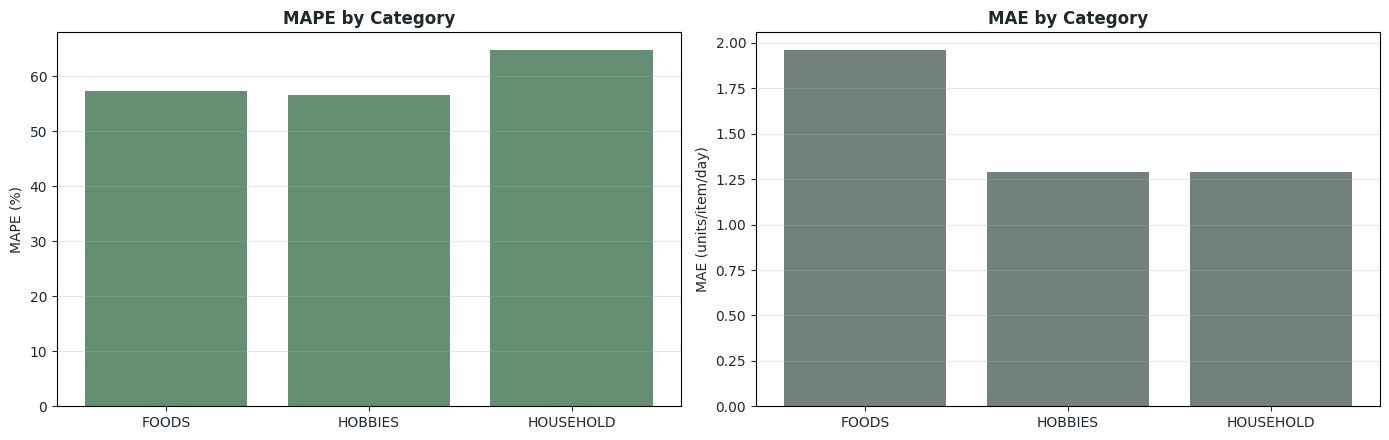

In [17]:
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), facecolor='white')

axes[0].bar(category_results.index, category_results['MAPE (%)'], color='#4A7C59', alpha=0.85)
axes[0].set_title('MAPE by Category', fontsize=12, fontweight='bold', color='#1F2A24')
axes[0].set_ylabel('MAPE (%)', color='#1F2A24')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(category_results.index, category_results['MAE'], color='#5B6B66', alpha=0.85)
axes[1].set_title('MAE by Category', fontsize=12, fontweight='bold', color='#1F2A24')
axes[1].set_ylabel('MAE (units/item/day)', color='#1F2A24')
axes[1].grid(True, alpha=0.3, axis='y')

for ax in axes:
    ax.set_facecolor('white')
    ax.tick_params(colors='#1F2A24')

plt.tight_layout()
plt.savefig('../images/category_breakdown_sku.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Summary: SKU-level, multi-category vs. category-level, single-category

`05_recursive_forecast.ipynb` forecast one smooth series: total daily sales across ~1,400 FOODS items in CA_1, and got a 5.5% recursive MAPE. This notebook forecasts 3,049 individual item-day series across all three categories with one global model, which is a substantially harder problem: each series is far noisier and, for many items, intermittent (frequent zero-sales days), so a model this size has less signal to work with per prediction.

In [18]:
print("=" * 60)
print("SUMMARY - SKU-LEVEL VS CATEGORY-LEVEL FORECASTING")
print("=" * 60)
print("\nCategory-level (04/05, CA_1 FOODS only, one aggregate series):")
print("  Recursive MAPE: 5.5%")
print(f"\nSKU-level (this notebook, CA_1 all categories, {len(item_categories):,} items):")
print(f"  Gradient Boosting - MAPE: {overall_mape:.1f}%  MAE: {overall_mae:.2f} units/item/day")
print(f"  Seasonal Naive    - MAPE: {seasonal_mape:.1f}%  MAE: {seasonal_mae:.2f} units/item/day")
print("\nBy category (Gradient Boosting / Seasonal Naive):")
for cat in category_results.index:
    gb_row = category_results.loc[cat]
    sn_row = seasonal_by_cat.loc[cat]
    print(f"  {cat:10s} GB  MAPE: {gb_row['MAPE (%)']:.1f}%  MAE: {gb_row['MAE']:.2f}")
    print(f"  {'':10s} SN  MAPE: {sn_row['MAPE (%)']:.1f}%  MAE: {sn_row['MAE']:.2f}")
print("\nWhy the SKU-level MAPE is higher than the category-level result:")
print("  The category-level model predicts one smooth, high-volume series")
print("  (total sales across ~1,400 FOODS items). The SKU-level model")
print(f"  predicts {len(item_categories):,} individual, much noisier, often")
print("  low-volume series, where a 1-2 unit miss on a slow-moving item")
print("  can swing MAPE sharply. A higher SKU-level MAPE is expected here,")
print("  not a regression - it reflects a genuinely harder problem.")
print("\nGradient Boosting vs seasonal naive - not a clean win either way:")
print("  GB wins MAPE by a wide margin, in every category. Seasonal naive")
print("  wins MAE, also in every category. GB's predictions lean on")
print("  rolling_mean_7 (dominant feature importance), so they behave like")
print("  a smoothed average - good for avoiding large percentage misses on")
print("  many low-volume items, less good at tracking sharp swings on the")
print("  higher-volume items that dominate a raw-unit metric like MAE.")
print("  Which model is 'better' genuinely depends on whether the intended")
print("  use case cares more about percentage accuracy or unit-level error.")
print("=" * 60)

SUMMARY - SKU-LEVEL VS CATEGORY-LEVEL FORECASTING

Category-level (04/05, CA_1 FOODS only, one aggregate series):
  Recursive MAPE: 5.5%

SKU-level (this notebook, CA_1 all categories, 3,049 items):
  Gradient Boosting - MAPE: 59.4%  MAE: 1.61 units/item/day
  Seasonal Naive    - MAPE: 83.3%  MAE: 1.36 units/item/day

By category (Gradient Boosting / Seasonal Naive):
  FOODS      GB  MAPE: 57.3%  MAE: 1.96
             SN  MAPE: 83.0%  MAE: 1.76
  HOBBIES    GB  MAPE: 56.6%  MAE: 1.29
             SN  MAPE: 91.2%  MAE: 1.12
  HOUSEHOLD  GB  MAPE: 64.7%  MAE: 1.29
             SN  MAPE: 80.2%  MAE: 0.95

Why the SKU-level MAPE is higher than the category-level result:
  The category-level model predicts one smooth, high-volume series
  (total sales across ~1,400 FOODS items). The SKU-level model
  predicts 3,049 individual, much noisier, often
  low-volume series, where a 1-2 unit miss on a slow-moving item
  can swing MAPE sharply. A higher SKU-level MAPE is expected here,
  not a regr

## Persisting the model and predictions

Everything above only exists in this notebook's kernel memory. A future Streamlit dashboard runs as a separate process, so it needs its own copy on disk of both the predictions (to show forecast vs. actual for the existing test window without re-running anything) and the trained model itself (to generate new on-demand forecasts beyond the fixed test window, via `recursive_forecast_multi`).

Saving the model alone isn't enough for correct on-demand forecasting later: `item_id_code` and the one-hot columns are only meaningful if the exact category vocabularies used to build them are saved and reused too, not recomputed from whatever subset of items happens to be loaded next time. `feature_cols` and `item_lookup` are saved alongside the model for the same reason, `item_lookup` is what `recursive_forecast_multi` iterates over to build each day's next-step rows for every item.

In [19]:
import joblib

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Predictions: everything needed for the forecast-vs-actual chart and the
# model-comparison numbers, with no model inference required to read it.
eval_df.to_csv('../data/processed/predictions_CA1_ALL.csv', index=False)

# Model plus the exact encodings it depends on: needed for on-demand recursive
# forecasting beyond the fixed 28-day test window.
joblib.dump({
    'model': model,
    'feature_cols': feature_cols,
    'item_categories': item_categories,
    'dept_categories': dept_categories,
    'cat_categories': cat_categories,
    'item_lookup': item_lookup,
    'lag_window': LAG_WINDOW
}, '../models/gbr_sku_ca1_all.joblib')

print(f"Predictions saved: ../data/processed/predictions_CA1_ALL.csv ({len(eval_df):,} rows)")
print("Model saved:       ../models/gbr_sku_ca1_all.joblib")

Predictions saved: ../data/processed/predictions_CA1_ALL.csv (85,372 rows)
Model saved:       ../models/gbr_sku_ca1_all.joblib
